<a href="https://colab.research.google.com/github/cm06/EMSC2010-Group-Project-3/blob/main/EMSC2010_Group_Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name: Ocean's Eleven Variables

Project week: 3 (Week 8)

Project title: Bayesian regression modelling of changing coral cover on the Barnards and Barren reefs

Datasets used (name and source):
Clean Data = https://anu365-my.sharepoint.com/:x:/g/personal/u7447903_anu_edu_au/IQBt9qZwAzaOS6-ceDOK3EkiAagFt_hNsHY_hrUc6nCgTfo?e=qZ4i6k

Raw Data = https://anu365-my.sharepoint.com/:x:/g/personal/u7447903_anu_edu_au/IQB65BOLJE4tRK1CQQifi2jmAZCTozxZvPZSyoedVcb_t98?e=InfRXL

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Charlotte | Leo | Yes| Add note|
| Data steward | Leo | Jiah | Yes| Add note|
| Analysis / modelling | Jiah | Emily | Yes| Add note|
| Visualisation / interpretation | Emily | Mel | Yes| Add note|
| Narrative | Mel | Georgia | Yes| Add note|
| Quality Control / Reproducibility  | Georgia | Charlotte | Yes| Add note|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

AIM:

Our aim for this project was to use Bayesian regression modelling to see how coral reef cover changes over time for two different reef locations; Barnards and Barren, tracking to see if there was a consistent trend in coral cover and if it differed in-between reef types.


DATA PREPARATION & COLLECTION:

The data was extrapolated from publically available AIMS monitoring programs in the Great Barrier Reef (data is linked above). The reef is divided into many smaller areas across the, some of which we excluded due to lack of yearly data availability and whether there was information on the depth of interest (2km).

We used a cleaned version of the dataset, with a time period across 2005 to 2024. To ensure consistency in the model and improve reliability the following was done:
- We removed any missing values
- We kept only relevant variables
- We made names uppercase
- Removed extra spaces and/or replaced with underscores

In [ ]:
# JIAH CODED DATA MODELLING
!pip install bambi #system command to install bambi package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 15.0 MB/s eta 0:00:00


In [ ]:
# Import required packages for data handling, plotting, modelling, and model comparison

import numpy as np
import matplotlib.pyplot as plt
import bambi as bmb
import arviz as az
import pandas as pd

We imported all the required libraries necessary for our modelling

In [ ]:
# Load the cleaned coral cover dataset from the Excel file

spreadsheet_name = 'CoralCover_Score_CleanData.xlsx'
worksheet_name = 'Sheet1'

df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

In [ ]:
# Clean column names by removing extra spaces, making names uppercase, and replacing spaces with underscores

df.columns = df.columns.str.strip().str.upper().str.replace(' ', '_')

# Display the first few rows to check that the dataset loaded correctly

df.head()

,REEF,DEPTH_(KM),YR,CORALCOVER.SCORE
0,Barnards,2,2005,0.733679
1,Barnards,2,2006,0.035000
2,Barnards,2,2007,0.044167
3,Barnards,2,2008,0.044167
4,Barnards,2,2009,0.096667


In [ ]:
# Count how many observations are available for each reef

df["REEF"].value_counts()

,count
REEF,
Barnards,20
Barren,20
Daydream,20
Dent,20
Double Cone,20
Dunk North,20
Dunk South,20
Fitzroy East,20
Fitzroy West,20


We counted the number of observations to ensure there is suffient data to compare against.

In [ ]:
# Define the columns used for modelling

reef_col="REEF"
x_col="YR"
y_col="CORALCOVER.SCORE"

In [ ]:
# Select the first two reef types from the dataset for comparison

reef_types = df[reef_col].dropna().unique()[:2]

reef_1 = reef_types[0]
reef_2 = reef_types[1]

# Print the reef types used in the analysis

print("Reef types used:" + str(reef_types))

Reef types used:['Barnards' 'Barren']


In [ ]:
# Filter the dataset so that only the two selected reef types are included

data = df[df[reef_col].isin([reef_1, reef_2])]

# Keep only the variables needed for modelling and remove missing values

data = data[[reef_col, x_col, y_col]].dropna()

We filtered the data so that only two reef types were chosen, so  for comparison purposes we could reduce noise and therby reduce errors in the modelling process.

/tmp/ipykernel_2541/2560760288.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ok" (-> color='k'). The keyword argument will take precedence.
  plt.plot(data[data[reef_col] == reef_1][x_col], data[data[reef_col] == reef_1][y_col], 'ok', color='indigo', label=reef_1)
/tmp/ipykernel_2541/2560760288.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ok" (-> color='k'). The keyword argument will take precedence.
  plt.plot(data[data[reef_col] == reef_2][x_col], data[data[reef_col] == reef_2][y_col], 'ok', color='hotpink', label=reef_2)


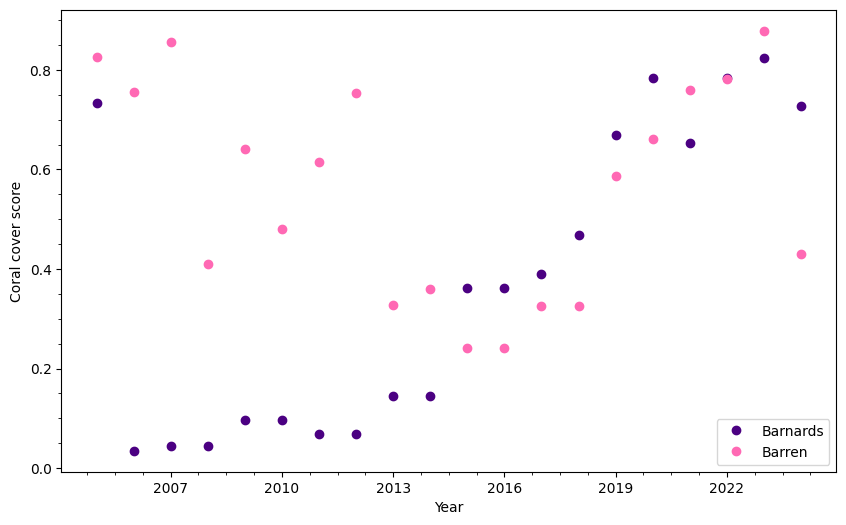

In [ ]:
# Plot coral cover score against year for the two selected reef types
# This gives an initial visual check of the relationship before modelling

from matplotlib.ticker import MaxNLocator #to clean up the major ticks on x-axis and make them integers

plt.figure(figsize=(10,6))

plt.plot(data[data[reef_col] == reef_1][x_col], data[data[reef_col] == reef_1][y_col], 'ok', color='indigo', label=reef_1)
plt.plot(data[data[reef_col] == reef_2][x_col], data[data[reef_col] == reef_2][y_col], 'ok', color='hotpink', label=reef_2)

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True)) #force integer ticks on x-axis

plt.xlabel("Year")
plt.ylabel("Coral cover score")

plt.legend()
plt.minorticks_on()

plt.show()

Scatter plot showing coral cover over time in the Barnards and Barren reefs.
This plot was created to visuable any potential trends in the dataset, and the differences between the two reefs, before we applied any further statistical analysis.

In [ ]:
# Scale the x variable (Year), so it has a mean of 0 and standard deviation of 1
# This helps the Bayesian correlation and regression models sample more reliably

data["x_scaled"] = (data[x_col] - np.mean(data[x_col])) / np.std(data[x_col])

# Create polynomial terms for testing increasingly complex regression models

data["x2_scaled"] = data["x_scaled"] ** 2
data["x3_scaled"] = data["x_scaled"] ** 3
data["x4_scaled"] = data["x_scaled"] ** 4

We scaled the dataset so that the models sampled more reliably and were more efficent.

In [ ]:
# Fit a straight-line model (first-order polynomial)

model_linear = bmb.Model("CORALCOVER.SCORE ~ x_scaled * REEF", data)
idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a quadratic model (second-order polynomial)

model_quadratic = bmb.Model("CORALCOVER.SCORE ~ x_scaled + x2_scaled * REEF", data)
idata_quadratic = model_quadratic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a cubic model (third-order polynomial)

model_cubic = bmb.Model("CORALCOVER.SCORE ~ x_scaled + x2_scaled + x3_scaled * REEF", data)
idata_cubic = model_cubic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a quartic model (fourth-order polynomial)

model_quartic = bmb.Model("CORALCOVER.SCORE ~ x_scaled + x2_scaled + x3_scaled + x4_scaled * REEF", data)
idata_quartic = model_quartic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

#false progress bars so that once in the Github it wasn't invalid


We added polynomial terms to allow for curved relationships in our model

In [ ]:
# Compare all fitted models using Arviz model comparison
# The model with rank 0 is considered the best-fitting model

az.compare({"linear": idata_linear, "quadratic": idata_quadratic, "cubic": idata_cubic, "quartic": idata_quartic})

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
cubic,0,6.551733,7.692656,0.000000,6.156882e-01,4.655788,0.000000,True,log
quartic,1,0.975404,8.167923,5.576329,1.133126e-01,4.554878,3.556852,True,log
quadratic,2,-0.096608,7.300045,6.648341,1.858714e-16,5.590204,4.977430,True,log
linear,3,-0.438462,6.954088,6.990195,2.709992e-01,8.133876,6.355171,True,log


The model comparison shows that the cubic model has rank 0, meaning it is the best-fitting model for the relationship between year and coral cover score across the two selected reef types.


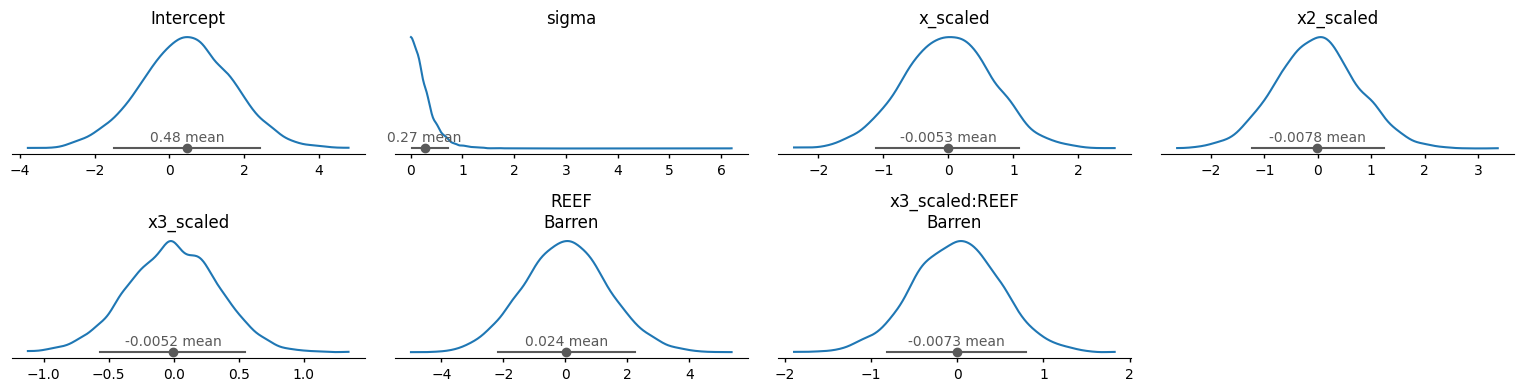

In [ ]:
#EMILY CODED DATA VISUALISATION AND INTERPRETATION

  #FOR OUR CHOSEN CUBIC MODEL:

#Plot the priors used by bambi
model_cubic.plot_priors()
plt.tight_layout() #So the plots don't overlap
plt.show()

We plotted out initial asssumptions of the data, they are rather broad and centered around 0 - indicating that there might not be a strong relationship between year and coral cover.


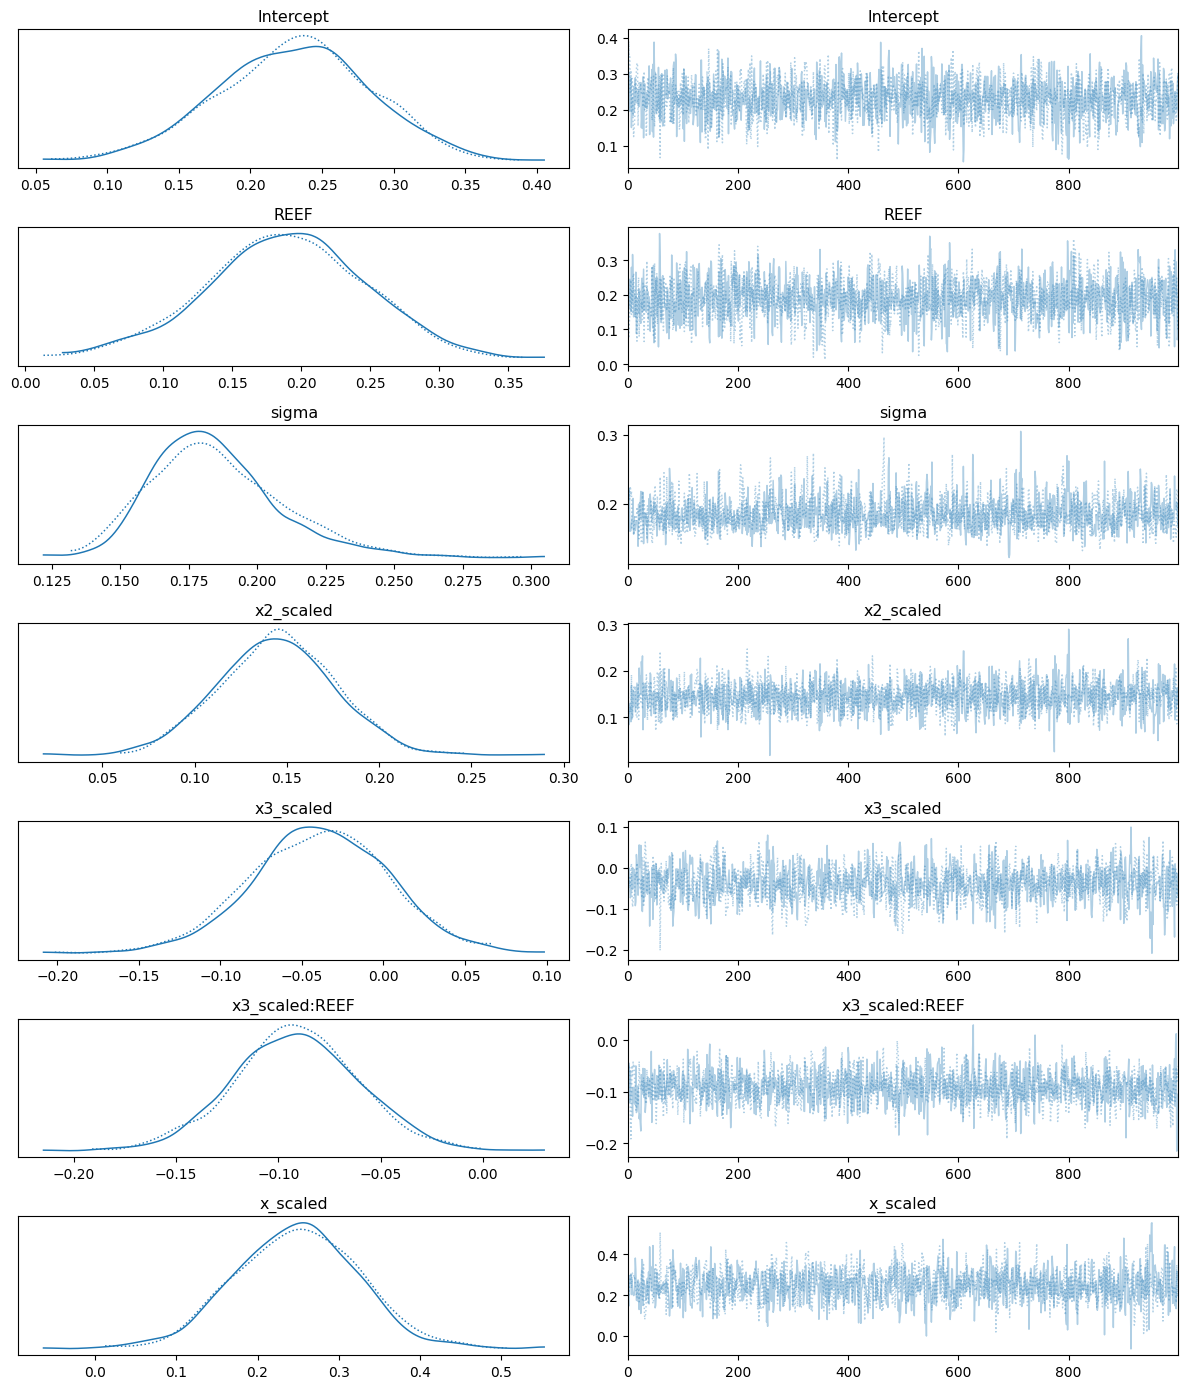

In [ ]:
#Use arviz to plot the sampled posterior distributions
az.plot_trace(idata_cubic);
plt.tight_layout() #To prevent the plots from overlapping

Posterior distributions for the regression models
The plots help to show that our data is reliable, as the MCMC chains have good overlap & converged.

/tmp/ipykernel_2541/2392015360.py:41: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_mean_reef1 = az.hdi(y_col_mean_draws_reef1, hdi_prob=0.95)
/tmp/ipykernel_2541/2392015360.py:42: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_pps_reef1 = az.hdi(y_col_pps_draws_reef1, hdi_prob=0.95)
/tmp/ipykernel_2541/2392015360.py:74: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_mean_reef2 = az.hdi(y_mean_draws_reef2, hdi_prob=0.95)
/tmp/ipykernel_2541/2392015360.py:75: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_pps_reef2 = az.hdi(y_

(0.0, 1.5)

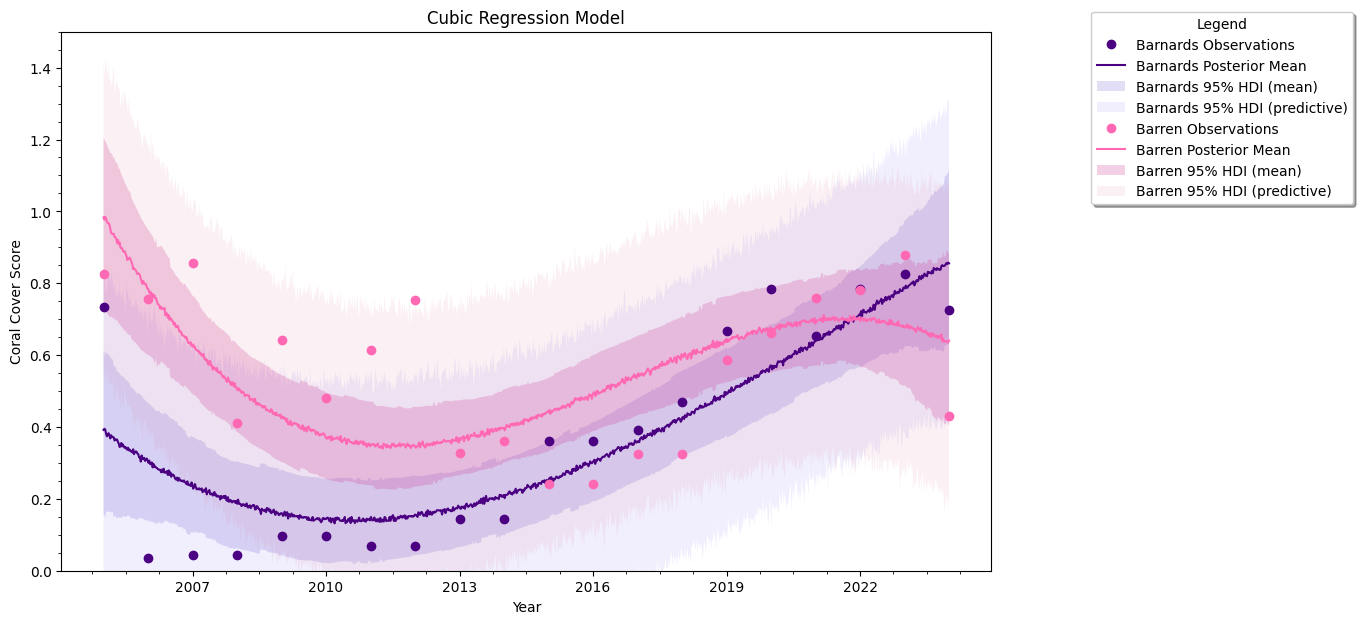

In [ ]:
  #CREATE PREDICTIVE RANGES FOR OUR MODEL

#Predict across a range of years from 2005 to 2024, and scale as above
x_range = np.linspace(2005, 2024, 1000)
x_range_scaled = (x_range - np.mean(data[x_col])) / np.std(data[x_col])

#Define scaled second- and third-order polynomial terms for the prediction range
x2_range_scaled = x_range_scaled ** 2
x3_range_scaled = x_range_scaled ** 3

  #BARNARDS PREDICTIONS

#Create a new dataframe for prediction with the scaled x-values and their first-, second-, and third- order polynomial terms
new_data_reef1 = pd.DataFrame({
    "x_scaled": x_range_scaled,
    "x2_scaled": x2_range_scaled,
    "x3_scaled": x3_range_scaled,
    "REEF": reef_1 #Barnards
})

#Predict the distribution of regression lines for each year
idata_predictions_reef1_params = model_cubic.predict(idata_cubic, data=new_data_reef1, kind='response_params', inplace=False) #"inplace=False" here means that we are not editing the data in place, so the dataframe is not changed

#Predict the distribution of cover scores for each year
idata_predictions_reef1_response = model_cubic.predict(idata_cubic, data=new_data_reef1, kind='response', inplace=False)

#Make random draws from the posterior of the regression lines
y_col_mean_draws_reef1 = idata_predictions_reef1_params.posterior["mu"].values

#Reshape to (total_draws, x_points)
y_col_mean_draws_reef1 = y_col_mean_draws_reef1.reshape(-1, len(x_range))

#Make random draws from the posterior of the reef coverage score
y_col_pps_draws_reef1 = idata_predictions_reef1_response.posterior_predictive[y_col].values

#Reshape to (total_draws, x_points)
y_col_pps_draws_reef1 = y_col_pps_draws_reef1.reshape(-1, len(x_range))

#Compute the mean and HDI of the posterior predictive distribution for Barnards
posterior_mean_reef1 = y_col_pps_draws_reef1.mean(axis=0)
hdi_mean_reef1 = az.hdi(y_col_mean_draws_reef1, hdi_prob=0.95)
hdi_pps_reef1 = az.hdi(y_col_pps_draws_reef1, hdi_prob=0.95)

  #BARREN PREDICTIONS

#Create a new dataframe for prediction with the scaled x-values and their first-, second-, and third-degree polynomial terms
new_data_reef2 = pd.DataFrame({
    "x_scaled": x_range_scaled,
    "x2_scaled": x2_range_scaled,
    "x3_scaled": x3_range_scaled,
    "REEF": reef_2 #Barren
})

#Predict the distribution of regression lines for each year
idata_predictions_reef2_params = model_cubic.predict(idata_cubic, data=new_data_reef2, kind='response_params', inplace=False)

#Predict the distribution of cover scores for each year
idata_predictions_reef2_response = model_cubic.predict(idata_cubic, data=new_data_reef2, kind='response', inplace=False)

#Make random draws from the posterior of the regression lines
y_mean_draws_reef2 = idata_predictions_reef2_params.posterior["mu"].values

#Reshape to (total_draws, x_points)
y_mean_draws_reef2 = y_mean_draws_reef2.reshape(-1, len(x_range))

#Make random draws from the posterior of the reef coverage score
y_pps_draws_reef2 = idata_predictions_reef2_response.posterior_predictive[y_col].values

#Reshape to (total_draws, x_points)
y_pps_draws_reef2 = y_pps_draws_reef2.reshape(-1, len(x_range))

#Compute the mean and HDI of the posterior predictive distribution for Barren
posterior_mean_reef2 = y_pps_draws_reef2.mean(axis=0)
hdi_mean_reef2 = az.hdi(y_mean_draws_reef2, hdi_prob=0.95)
hdi_pps_reef2 = az.hdi(y_pps_draws_reef2, hdi_prob=0.95)

  #PLOT BOTH POSTERIOR FOR REGRESSION LINES AND THE OBSERVATIONS

plt.figure(figsize=(12, 7)) #Increase figure size for better visibility, as the plot is quite busy

  #BARNARDS PLOT

plt.plot(data[data[reef_col] == reef_1][x_col], data[data[reef_col] == reef_1][y_col], 'ok', color='indigo', label=f'{reef_1} Observations') #Barnards observations
plt.plot(x_range, posterior_mean_reef1, color="indigo", label=f'{reef_1} Posterior Mean') #Posterior mean
plt.fill_between(
    x_range,
    hdi_mean_reef1[:, 0],
    hdi_mean_reef1[:, 1],
    alpha=0.2,
    color="slateblue",
    label=f'{reef_1} 95% HDI (mean)',
    edgecolor = None
)
plt.fill_between(
    x_range,
    hdi_pps_reef1[:, 0],
    hdi_pps_reef1[:, 1],
    alpha=0.1,
    color="mediumslateblue",
    label=f'{reef_1} 95% HDI (predictive)',
    edgecolor = None
)

  #BARREN PLOT

plt.plot(data[data[reef_col] == reef_2][x_col], data[data[reef_col] == reef_2][y_col], 'ok', color='hotpink', label=f'{reef_2} Observations') #Barren observations
plt.plot(x_range, posterior_mean_reef2, color="hotpink", label=f'{reef_2} Posterior Mean') #Posterior mean
plt.fill_between(
    x_range,
    hdi_mean_reef2[:, 0],
    hdi_mean_reef2[:, 1],
    alpha=0.2,
    color="mediumvioletred",
    label=f'{reef_2} 95% HDI (mean)',
    edgecolor = None
)
plt.fill_between(
    x_range,
    hdi_pps_reef2[:, 0],
    hdi_pps_reef2[:, 1],
    alpha=0.1,
    color="palevioletred",
    label=f'{reef_2} 95% HDI (predictive)',
    edgecolor = None
)

  #LABELS & TITLES

plt.legend( bbox_to_anchor=(1.1,1.05),shadow=True,title='Legend') #Anchor the legend outside the plot
plt.minorticks_on()
plt.xlabel("Year")
plt.ylabel("Coral Cover Score")
plt.title("Cubic Regression Model")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

#Restrict the y-axis to show only non-negative reef coverage scores
ax = plt.gca()
ax.set_ylim([0,1.50])

Overall, the data - particularly for Barnards - seem to be fairly well explained by our cubic model. The relationship here shows coverage for both reefs reaching a minimum around 2010-2011, then increasing until about 2021. From this model, we can see a similarity in the variation in reef coverage for the wet tropics and Fitzroy regions, which indicates that they may be affected by some of the same factors (e.g. temperature, pH of the ocean off the Queensland coast). The negative predictive values are acknowledged as a limitation of our model, and have been eliminated as it is not possible to have less than zero reef coverage.

 - The posterior represent the models best estimation of coral cover and the HDI % represented the range of values where the true value is likely to lay.
 - However the model was limited in that there was an increasing uncertainty as the models moved out towards the unobserved range.

How accurate do we think this model is?

/tmp/ipykernel_434/1460114733.py:41: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_mean_reef1 = az.hdi(y_col_mean_draws_reef1, hdi_prob=0.95)
/tmp/ipykernel_434/1460114733.py:42: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_pps_reef1 = az.hdi(y_col_pps_draws_reef1, hdi_prob=0.95)
/tmp/ipykernel_434/1460114733.py:74: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_mean_reef2 = az.hdi(y_mean_draws_reef2, hdi_prob=0.95)
/tmp/ipykernel_434/1460114733.py:75: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_pps_reef2 = az.hdi(y_pps_

(2005.0, 2040.0)

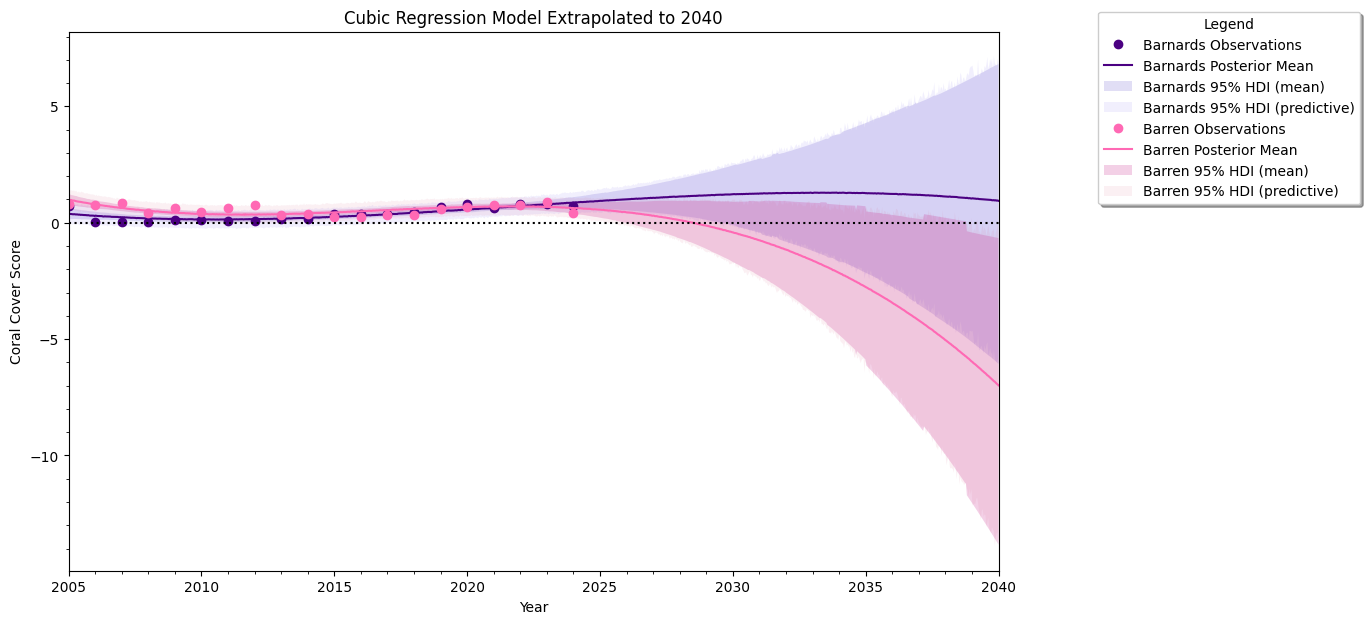

In [ ]:
  #EXTRAPOLATION - MODEL PRACTICABILITY

#Extend the prediction range to 2040
x_range = np.linspace(2005, 2040, 1000)
x_range_scaled = (x_range - np.mean(data[x_col])) / np.std(data[x_col])

#Define scaled second- and third-order polynomial terms for the prediction range
x2_range_scaled = x_range_scaled ** 2
x3_range_scaled = x_range_scaled ** 3

  #BARNARDS PREDICTIONS

#Create a new dataframe for prediction with the scaled x-values and their first-, scond-, and third- order polynomial terms
new_data_reef1 = pd.DataFrame({
    "x_scaled": x_range_scaled,
    "x2_scaled": x2_range_scaled,
    "x3_scaled": x3_range_scaled,
    "REEF": reef_1 #Barnards
})

#Predict the distribution of regression lines at each year
idata_predictions_reef1_params = model_cubic.predict(idata_cubic, data=new_data_reef1, kind='response_params', inplace=False) #"inplace=False" here means that we are not editing the data in place, so the dataframe is not changed

#Predict the distribution of cover scores for each year
idata_predictions_reef1_response = model_cubic.predict(idata_cubic, data=new_data_reef1, kind='response', inplace=False)

#Make random draws from the posterior of the regression lines
y_col_mean_draws_reef1 = idata_predictions_reef1_params.posterior["mu"].values

#Reshape to (total_draws, x_points)
y_col_mean_draws_reef1 = y_col_mean_draws_reef1.reshape(-1, len(x_range))

#Make random draws from the posterior of the reef coverage score
y_col_pps_draws_reef1 = idata_predictions_reef1_response.posterior_predictive[y_col].values

#Reshape to (total_draws, x_points)
y_col_pps_draws_reef1 = y_col_pps_draws_reef1.reshape(-1, len(x_range))

#Compute mean and HDI of the posterior predictive distribution for Barnards
posterior_mean_reef1 = y_col_pps_draws_reef1.mean(axis=0)
hdi_mean_reef1 = az.hdi(y_col_mean_draws_reef1, hdi_prob=0.95)
hdi_pps_reef1 = az.hdi(y_col_pps_draws_reef1, hdi_prob=0.95)

  #BARREN PREDICTIONS

#Create a new dataframe for prediction with the scaled x-values and their first-, second-, and third-degree polynomial terms
new_data_reef2 = pd.DataFrame({
    "x_scaled": x_range_scaled,
    "x2_scaled": x2_range_scaled,
    "x3_scaled": x3_range_scaled,
    "REEF": reef_2 #Barren
})

#Predict the distribution of regression lines at each year
idata_predictions_reef2_params = model_cubic.predict(idata_cubic, data=new_data_reef2, kind='response_params', inplace=False)

#Predict the distribution of cover scores for each year
idata_predictions_reef2_response = model_cubic.predict(idata_cubic, data=new_data_reef2, kind='response', inplace=False)

#Make random draws from the posterior of the regression lines
y_mean_draws_reef2 = idata_predictions_reef2_params.posterior["mu"].values

#Reshape to (total_draws, x_points)
y_mean_draws_reef2 = y_mean_draws_reef2.reshape(-1, len(x_range))

#Make random draws from the posterior of the reef coverage score
y_pps_draws_reef2 = idata_predictions_reef2_response.posterior_predictive[y_col].values

#Reshape to (total_draws, x_points)
y_pps_draws_reef2 = y_pps_draws_reef2.reshape(-1, len(x_range))

#Compute mean and HDI of the posterior predictive distribution for Barren
posterior_mean_reef2 = y_pps_draws_reef2.mean(axis=0)
hdi_mean_reef2 = az.hdi(y_mean_draws_reef2, hdi_prob=0.95)
hdi_pps_reef2 = az.hdi(y_pps_draws_reef2, hdi_prob=0.95)

  #PLOT BOTH POSTERIOR FOR REGRESSION LINES AND THE OBSERVATIONS

plt.figure(figsize=(12, 7)) #Increase figure size for better visibility, as the plot is quite busy

  #BARNARDS PLOT

plt.plot(data[data[reef_col] == reef_1][x_col], data[data[reef_col] == reef_1][y_col], 'ok', color='indigo', label=f'{reef_1} Observations') #Barnards observations
plt.plot(x_range, posterior_mean_reef1, color="indigo", label=f'{reef_1} Posterior Mean') #Posterior mean
plt.fill_between(
    x_range,
    hdi_mean_reef1[:, 0],
    hdi_mean_reef1[:, 1],
    alpha=0.2,
    color="slateblue",
    label=f'{reef_1} 95% HDI (mean)',
    edgecolor = None
)
plt.fill_between(
    x_range,
    hdi_pps_reef1[:, 0],
    hdi_pps_reef1[:, 1],
    alpha=0.1,
    color="mediumslateblue",
    label=f'{reef_1} 95% HDI (predictive)',
    edgecolor = None
)

  #BARREN PLOT

plt.plot(data[data[reef_col] == reef_2][x_col], data[data[reef_col] == reef_2][y_col], 'ok', color='hotpink', label=f'{reef_2} Observations') #Barren observations
plt.plot(x_range, posterior_mean_reef2, color="hotpink", label=f'{reef_2} Posterior Mean') #Posterior mean
plt.fill_between(
    x_range,
    hdi_mean_reef2[:, 0],
    hdi_mean_reef2[:, 1],
    alpha=0.2,
    color="mediumvioletred",
    label=f'{reef_2} 95% HDI (mean)',
    edgecolor = None
)
plt.fill_between(
    x_range,
    hdi_pps_reef2[:, 0],
    hdi_pps_reef2[:, 1],
    alpha=0.1,
    color="palevioletred",
    label=f'{reef_2} 95% HDI (predictive)',
    edgecolor = None
)

  #LABELS & TITLES

plt.legend( bbox_to_anchor=(1.1,1.05),shadow=True,title='Legend') #Anchor the legend outside the plot
plt.minorticks_on()
plt.xlabel("Year")
plt.ylabel("Coral Cover Score")
plt.title("Cubic Regression Model Extrapolated to 2040")

#DASHED Y=0 LINE
plt.axhline(y=0, color="black", linestyle=":")

#LIMIT GRAPH
plt.xlim(2005, 2040)

This graph was created by extending the predictions to 2040. According to our cubic model, Barnards reef coverage may either increase or decrease while Barren will continue to decrease over the 16-year period beyond the data observations. We know that climate factors are decreasing reef coverage **in general**; however, this model allows for only limited variation in coverage, and so may not be practicable for long-term predictions. A continuous downward trend might not encapsulate the complexity of factors impacting coverage - for example, insolation impacts reef health and varies according to a cycle.

A more accurate model would be asymptotic, or would give a constant predicted mean of zero beyond the x-intercept shown. However, if we ignore the negative predictions for reef coverage scores, we can see that what our model does a good job of is showing the variation in coverage over the period we are looking at, and predicting a general trend.

**Week 8 Group Project Reflections:**

**Jiah -** For the Week 8 group project, I contributed as the Analysis/Data Modelling lead, focusing on analysing the dataset and implementing regression models to understand how coral cover changed over time for two different reef types. I presented the cleaned dataset in the notebook, scaled the year variable, and fitted multiple regression models (linear, quadratic, cubic and quartic) to test which best described the relationship.
I then compared the various regression models and found out that the cubic model represented the best fit. Overall, this role helped me build confidence in applying regression modelling and interpreting statistical results in a structured and systematic way.


**Emily** - I was the Visualisation and Interpretation lead for this project. For this role, I had to try to present our model in a way that would help us and others understand the data. I started by plotting our prior and posterior distributions from Jiah's modeliing, then used the chosen model to make predictions for the variables we were interested in. I chose to visualise our model in the way that seemed most useful for interpreting the data, by eliminating unrelistic predictions and keeping the colour scheme consistent, and I enjoyed figuring out how to manipulate plots to help interpret the model. After creating each plot I added a figure caption to explain it. I definitely found this the most challenging of the roles I've had so far - I Googled a lot of things and had to try several times to get the main plot to work. I found what helped most was to go over the class activities from last week and make a list of the things I needed to do before starting. As someone who has avoided coding in the past, I ultimately found this a good opportunity.

**Leo:** I was the data steward for this project. My role was to supply the group workbook with clear, concise data that was relevant to our idea. I first found the raw data (linked at the top of the notebook) and, in excel, sorted through all of the raw data to seperate the relevant information. In this case, I found that the dates, location, depth, and coral cover score to be key in creating our models. I then also added the cleaned data at the top of the notebook for easy access for the group. This role made me think critically about what my group needed to complete their roles and was challenging in the sense of finding suitable data wasn't as straightforward as I had believed it to be.

**Mel:** I was the narrative lead for this project. This role concerned the matter of marking down and explaining all coding decisions within the notebook, highlighting the key decisions as well as the limitations within our notebook. In addition, I made sure the notebook itself flowed in a logical manner as according to our research aims. I checked over the notes made in each code section before summarising them at the bottom in a marker cell, then highlighted the limitations of the models, and use this data to define the hypothesis for our task. Overall I found that this task improved my understanding of the need for cohesion for future reproducibility, and detailed analysis in explaining your research to others.

**Charlotte:** My role for this week's project was role 1, Github and Intergration. My main responsibilies were creating the group's shared colab and making sure everyone could access it through a link on our group's canvas page. I was also in charge of commiting the colab to Github and making sure that our data source for this week was added. Overall, this role allowed me to become more comfortable with Colab and Github and I'm sure it will come in handy for future uses of both the programs

**Georgie:** My role for this project was quality control & reproducibility. I made sure that our dataset was accessible and the source was clearly stated & included metadata, and I checked all the code to ensure it ran smoothly. I made some spelling and wording adjustments to the explanations and also made some minor changes to the code to make some graphs axes look cleaner. I also added some figure captions where I felt it was unclear.
